# Generalized Linear Models - landslides (NCA) -

Model to predict landslide susceptibility in the northern Colombian Andes, considering local and catchment-scale variables

In [ ]:
install.packages('pscl')

In [ ]:
library(lme4) 
library(brms)
require(rgdal)
library(sp) 
library(effects)
library(mgcv)

In [214]:
shp <- readOGR(dsn = "G:/My Drive/INVESTIGACION/POSDOC/GLM/landslides/PUNTOS_FINAL/", layer = "PUNTOS_FINAL")

Warning message:
"OGR support is provided by the sf and terra packages among others"
Warning message:
"OGR support is provided by the sf and terra packages among others"
Warning message:
"OGR support is provided by the sf and terra packages among others"
Warning message:
"OGR support is provided by the sf and terra packages among others"
Warning message:
"OGR support is provided by the sf and terra packages among others"
Warning message:
"OGR support is provided by the sf and terra packages among others"


OGR data source with driver: ESRI Shapefile 
Source: "G:\My Drive\INVESTIGACION\POSDOC\GLM\landslides\PUNTOS_FINAL", layer: "PUNTOS_FINAL"
with 6189 features
It has 50 fields
Integer64 fields read as strings:  FID_Puntos FID_1 FID_punt_1 FID_Datos_ fid_ ID_CUENCA MenM 


In [215]:
str(df)

Formal class 'SpatialPointsDataFrame' [package "sp"] with 5 slots
  ..@ data       :'data.frame':	6193 obs. of  46 variables:
  .. ..$ FID_puntos: chr [1:6193] "1510" "2434" "508" "1201" ...
  .. ..$ FID_Datos_: chr [1:6193] "334" "334" "334" "336" ...
  .. ..$ fid_      : chr [1:6193] "0" "0" "0" "0" ...
  .. ..$ ID_CUENCA : chr [1:6193] "334" "334" "334" "336" ...
  .. ..$ Nombre    : chr [1:6193] "Quebrada Colorado" "Quebrada Colorado" "Quebrada Colorado" "Río Tarena Llorandó" ...
  .. ..$ kmeans    : chr [1:6193] "A" "A" "A" "B" ...
  .. ..$ tskmeans_s: chr [1:6193] "A" "A" "A" "B" ...
  .. ..$ hc        : chr [1:6193] "A" "A" "A" "B" ...
  .. ..$ Área      : num [1:6193] 22.1 22.1 22.1 87 87 ...
  .. ..$ hypso_inte: num [1:6193] 0.221 0.221 0.221 0.368 0.368 0.368 0.368 0.286 0.286 0.286 ...
  .. ..$ Knickpoint: chr [1:6193] "A" "A" "A" "D" ...
  .. ..$ X_Ksmean  : num [1:6193] 6.12 6.12 6.12 70.39 70.39 ...
  .. ..$ X_Ksmax   : num [1:6193] 10.3 10.3 10.3 231 231 ...
  .. ..$ X_K

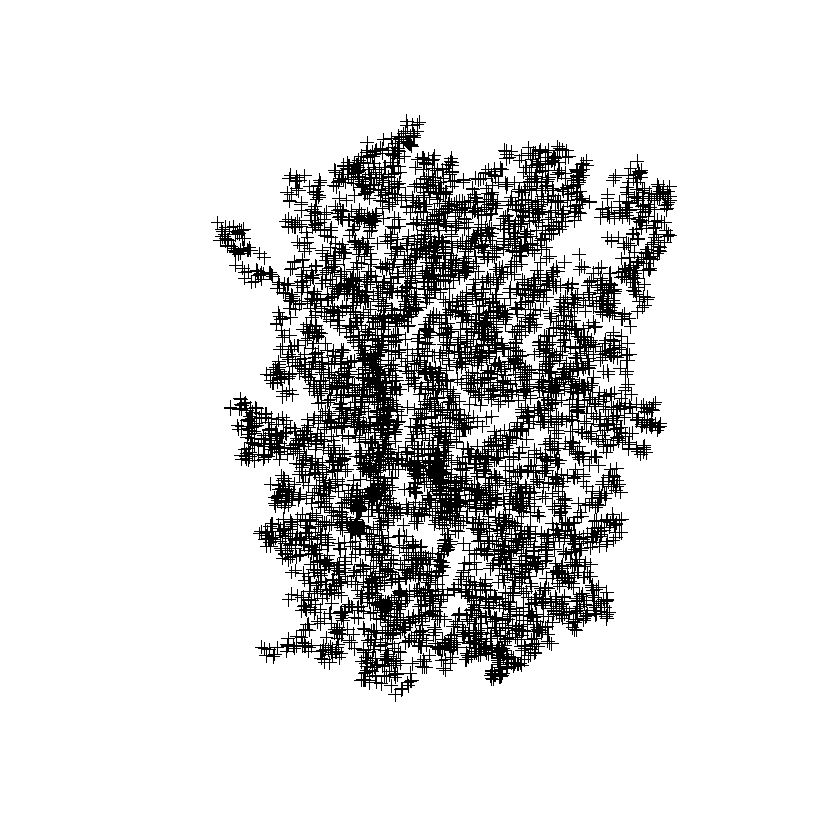

In [26]:
plot(df)

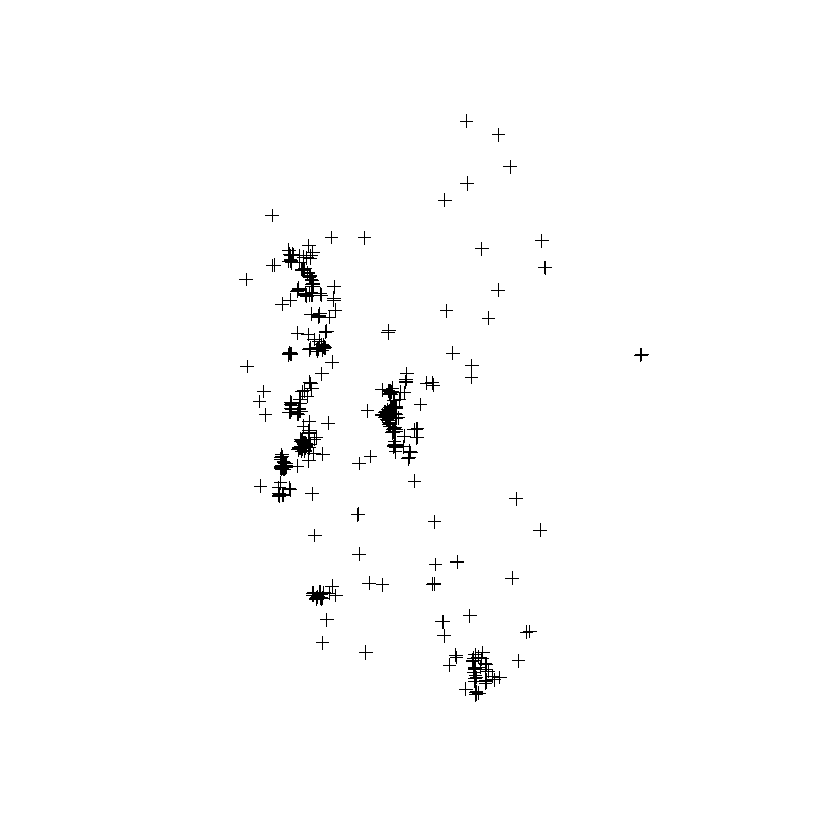

In [31]:
df_con=subset(df,MenM>0)
plot(df_con)

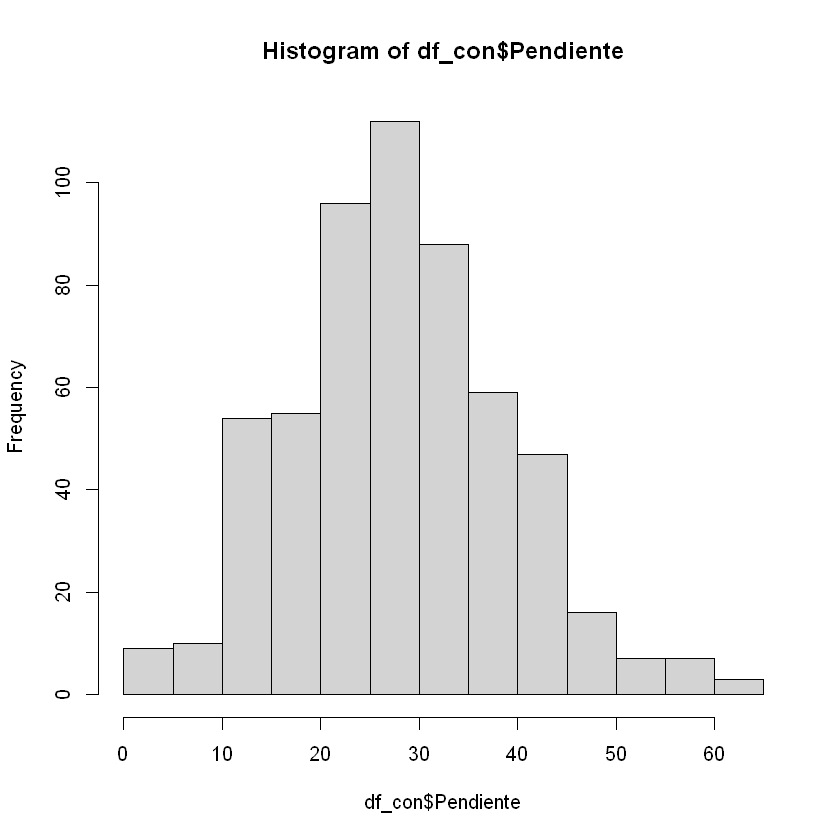

In [120]:
hist(df_con$Pendiente)

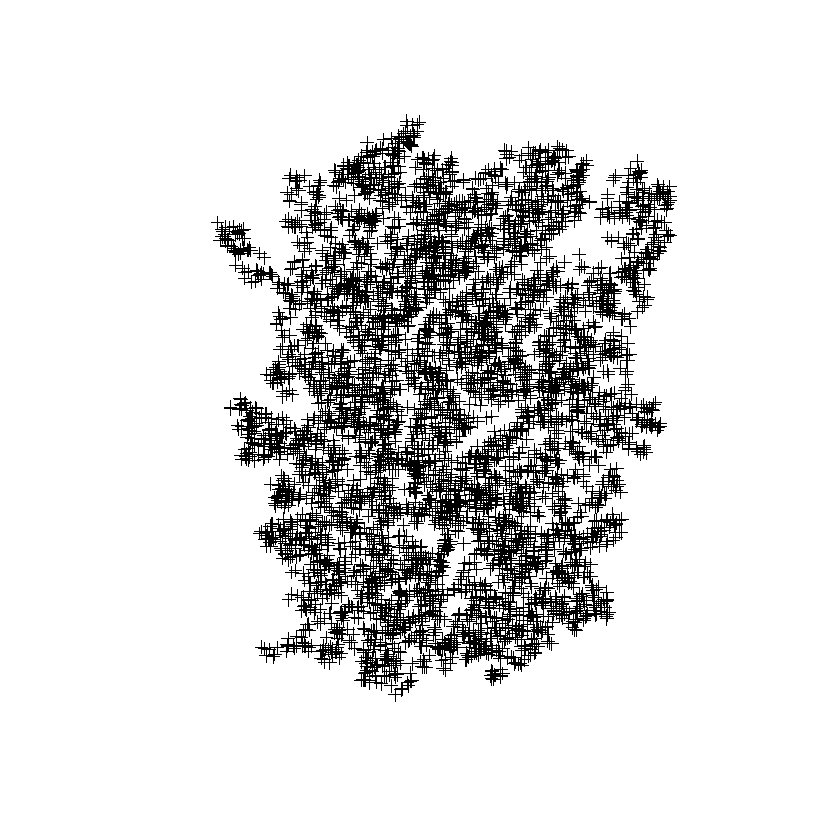

In [161]:
df_sin=subset(df,MenM<1)
plot(df_sin)

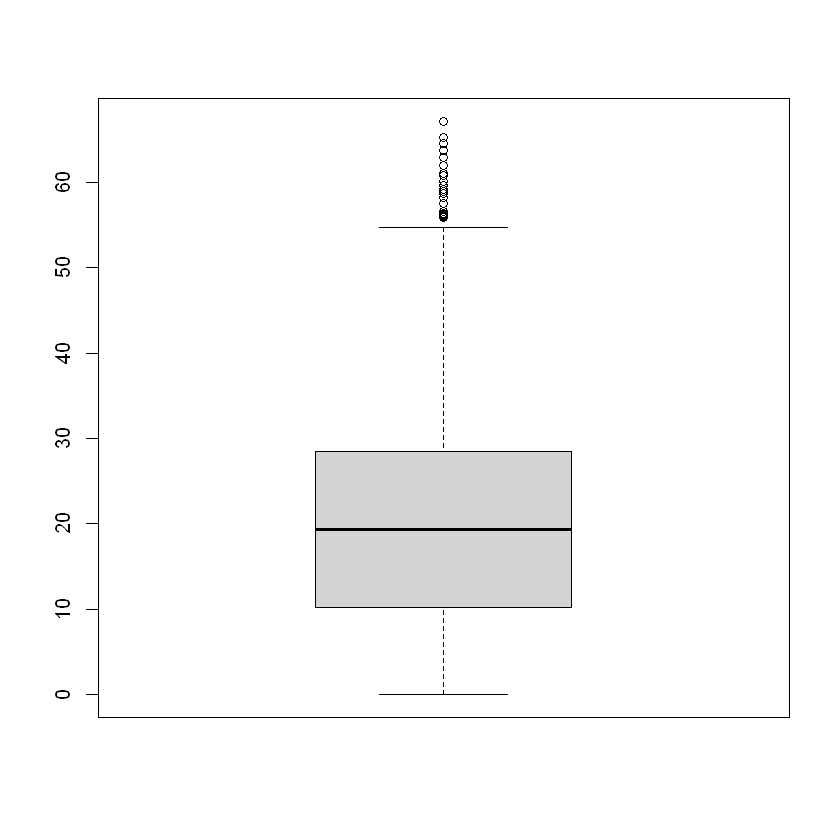

In [163]:
boxplot(df_sin$Pendiente)

In [39]:
dfm=as.data.frame(df)

In [142]:
X=subset(dfm,select=c('kmeans','hypso_inte','Área','X_Ksmean','X_chimean','Densidad','rainfall_c','elev_mean','slope_mean','rel_mean','Pendiente','Cobertura','Curvatura','Aspecto','MenM'))

In [46]:
head(X,2)

,kmeans,hypso_inte,Área,X_Ksmean,X_chimean,Densidad,rainfall_c,elev_mean,slope_mean,rel_mean,Elevacion,Pendiente,Cobertura,Curvatura,Aspecto,MenM
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<int>
1,A,0.221,22.12476,6.120693,7.531762,2.395506,7053.596,147.1276,9.942034,73.82659,143,1.62014,2,0.00,225.000,0
2,A,0.221,22.12476,6.120693,7.531762,2.395506,7053.596,147.1276,9.942034,73.82659,157,38.20790,2,-1.28,332.784,0


In [47]:
names(X)

[1] "kmeans"     "hypso_inte" "Área"       "X_Ksmean"   "X_chimean" 
 [6] "Densidad"   "rainfall_c" "elev_mean"  "slope_mean" "rel_mean"  
[11] "Elevacion"  "Pendiente"  "Cobertura"  "Curvatura"  "Aspecto"   
[16] "MenM"

In [143]:
X$Pendiente<-replace(X$Pendiente, X$Pendiente<0, 0) 

## Linear regression

In [183]:
lm=lm(MenM~1,data=X)
summary(lm)


Call:
lm(formula = MenM ~ 1, data = X)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.09091 -0.09091 -0.09091 -0.09091  0.90909 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.090909   0.003653   24.88   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.2875 on 6192 degrees of freedom


In [184]:
lm <- lm(formula = MenM ~ hypso_inte,data = X)
summary(lm)


Call:
lm(formula = MenM ~ hypso_inte, data = X)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.14347 -0.10344 -0.09014 -0.07136  0.93818 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.03321    0.01168   2.844  0.00447 ** 
hypso_inte   0.14451    0.02778   5.201 2.04e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.2869 on 6191 degrees of freedom
Multiple R-squared:  0.004351,	Adjusted R-squared:  0.00419 
F-statistic: 27.05 on 1 and 6191 DF,  p-value: 2.042e-07


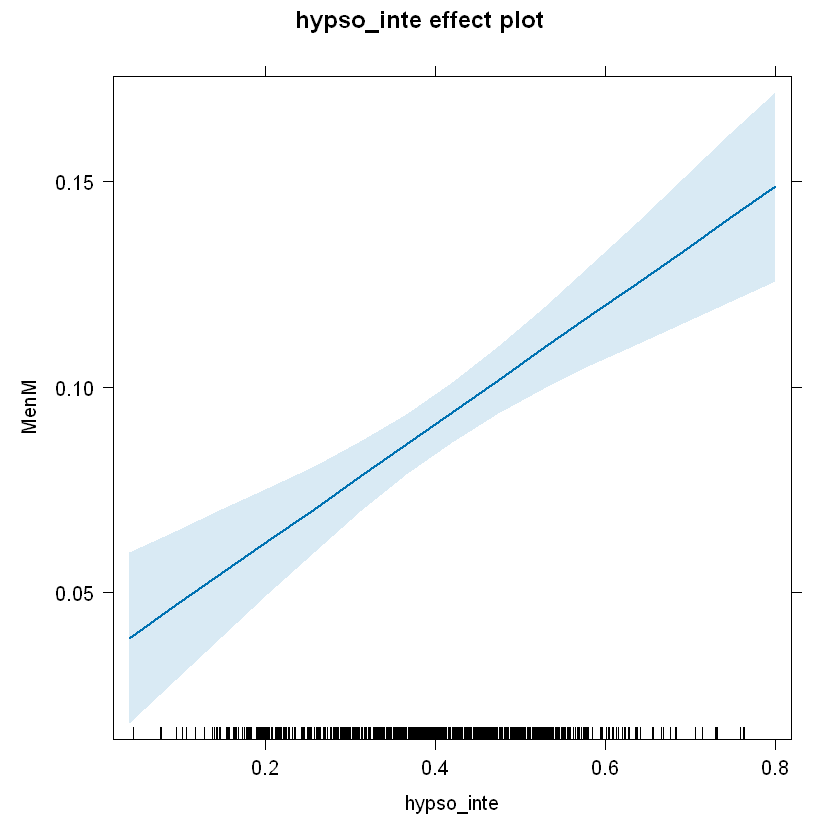

In [185]:
plot(allEffects(lm))

In [186]:
lm <- lm(formula = MenM ~ Pendiente,data = X)
summary(lm)


Call:
lm(formula = MenM ~ Pendiente, data = X)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.31442 -0.12234 -0.07496 -0.02735  1.00345 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.003448   0.006780  -0.509    0.611    
Pendiente    0.004735   0.000289  16.384   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.2815 on 6191 degrees of freedom
Multiple R-squared:  0.04156,	Adjusted R-squared:  0.0414 
F-statistic: 268.4 on 1 and 6191 DF,  p-value: < 2.2e-16


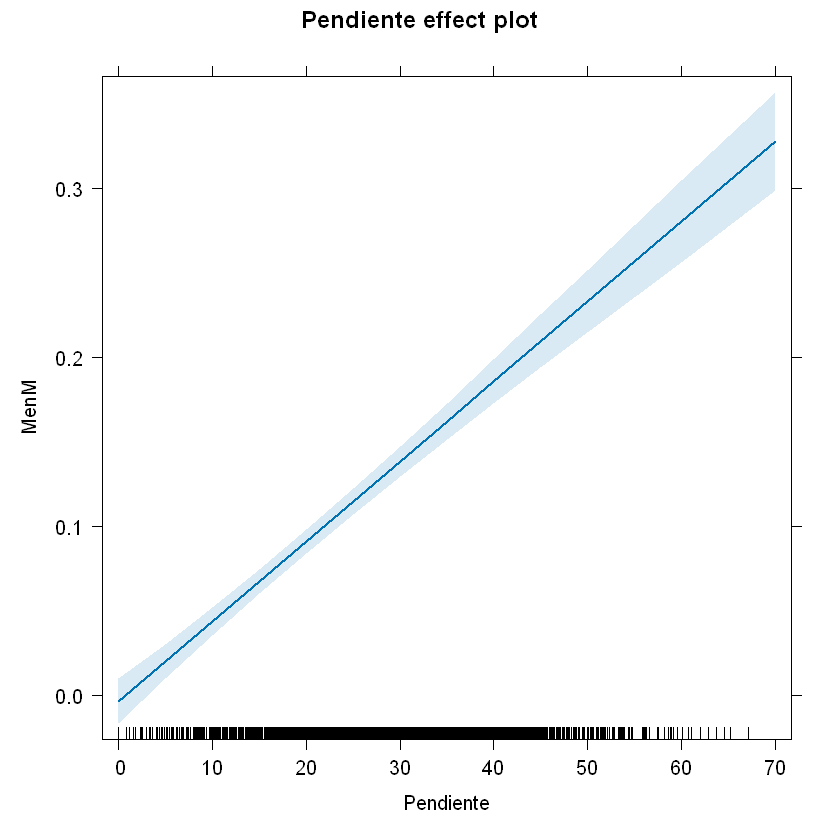

In [145]:
plot(allEffects(lm))

In [191]:
# Se eliminaron por no ser estadisticamente significativas: Aspecto (AIC:1311)
# Se saco Kmeans pq va a ser la variable fija (AIC:1310)
# Se saca coberturas por que todas las clases no son estadisticamente significativas: Aspecto (AIC:1364)
# se saca cobertura por que no es esatdsiticamente significativa
# y se saca densidad por que en a nivel de cuenca y por que le cambia el signo a hypso_inte
lm <- lm(formula = MenM ~  hypso_inte + Pendiente + Cobertura,data = X)
summary(lm)


Call:
lm(formula = MenM ~ hypso_inte + Pendiente + Cobertura, data = X)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.38662 -0.12293 -0.07283 -0.02533  1.02276 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.0930236  0.0815150  -1.141   0.2538    
hypso_inte   0.0026733  0.0282776   0.095   0.9247    
Pendiente    0.0051030  0.0003029  16.847   <2e-16 ***
Cobertura0  -0.0235428  0.1807081  -0.130   0.8963    
Cobertura1   0.1667331  0.0854777   1.951   0.0511 .  
Cobertura2   0.0569495  0.0809393   0.704   0.4817    
Cobertura3   0.1174916  0.0810165   1.450   0.1470    
Cobertura4   0.0016433  0.1400057   0.012   0.9906    
Cobertura5   0.0923317  0.1491018   0.619   0.5358    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.2799 on 6184 degrees of freedom
Multiple R-squared:  0.05333,	Adjusted R-squared:  0.0521 
F-statistic: 43.54 on 8 and 6184 DF,  p-value: < 2.2e-16


## Logistic regression

In [192]:
glm <- glm(formula = MenM ~ hypso_inte + Pendiente + Cobertura,family=binomial,data = X)
summary(glm)


Call:
glm(formula = MenM ~ hypso_inte + Pendiente + Cobertura, family = binomial, 
    data = X)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -16.818510 412.791297  -0.041    0.968    
hypso_inte    0.281563   0.396131   0.711    0.477    
Pendiente     0.059284   0.003783  15.672   <2e-16 ***
Cobertura0   -0.363989 904.926949   0.000    1.000    
Cobertura1   13.770650 412.791367   0.033    0.973    
Cobertura2   12.688060 412.791274   0.031    0.975    
Cobertura3   13.418690 412.791274   0.033    0.974    
Cobertura4   -0.163370 693.162411   0.000    1.000    
Cobertura5    1.179200 770.674977   0.002    0.999    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 3773.2  on 6192  degrees of freedom
Residual deviance: 3452.4  on 6184  degrees of freedom
AIC: 3470.4

Number of Fisher Scoring iterations: 14


In [193]:
with(summary(glm), 1 - deviance/null.deviance)

[1] 0.08502079

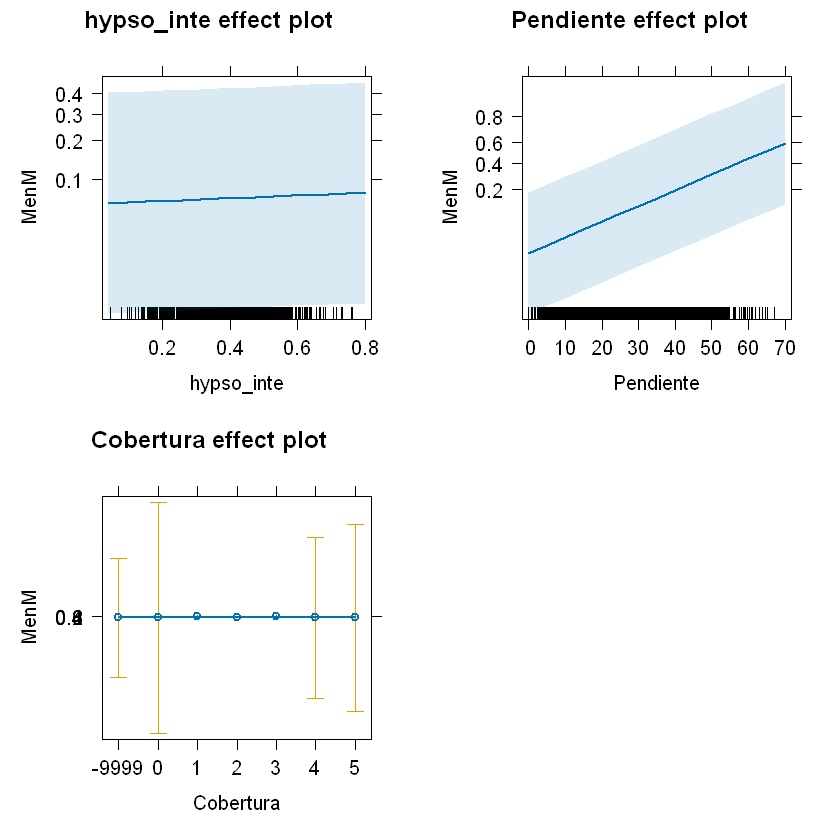

In [194]:
plot(allEffects(glm))

## GAMs

In [196]:
gamm=gam(formula = MenM ~ hypso_inte + s(Pendiente) + Cobertura, family = binomial(link=logit),data = X,method="REML")
summary(gamm)

Warning message in newton(lsp = lsp, X = G$X, y = G$y, Eb = G$Eb, UrS = G$UrS, L = G$L, :
"Fitting terminated with step failure - check results carefully"



Family: binomial 
Link function: logit 

Formula:
MenM ~ hypso_inte + s(Pendiente) + Cobertura

Parametric coefficients:
              Estimate Std. Error z value Pr(>|z|)
(Intercept) -2.804e+01  1.870e+05   0.000    1.000
hypso_inte   8.758e-03  4.055e-01   0.022    0.983
Cobertura0  -7.949e+00  3.875e+07   0.000    1.000
Cobertura1   2.627e+01  1.870e+05   0.000    1.000
Cobertura2   2.505e+01  1.870e+05   0.000    1.000
Cobertura3   2.581e+01  1.870e+05   0.000    1.000
Cobertura4  -7.687e+00  2.740e+07   0.000    1.000
Cobertura5  -5.235e+00  3.001e+07   0.000    1.000

Approximate significance of smooth terms:
               edf Ref.df Chi.sq p-value    
s(Pendiente) 3.933  4.922  216.9  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.054   Deviance explained = 9.86%
-REML = 1639.1  Scale est. = 1         n = 6193

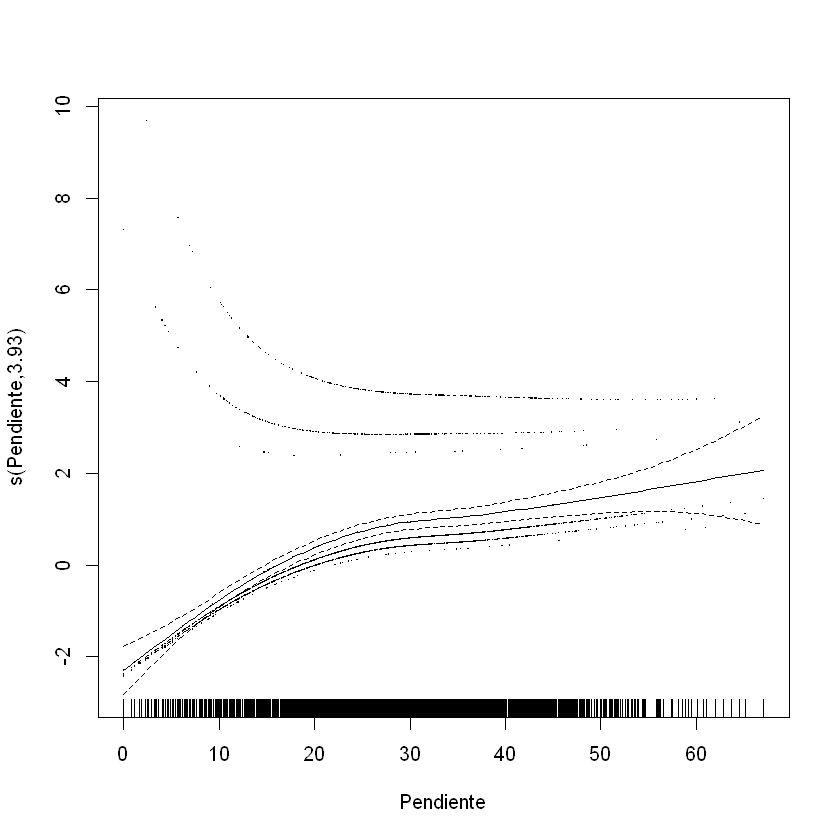

In [203]:
plot(gamm,residuals=TRUE)

## HGLM

In [199]:
hglm <- glmer(formula = MenM ~ 1 + (1|kmeans),family=binomial,data=X)
summary(hglm)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: MenM ~ 1 + (1 | kmeans)
   Data: X

     AIC      BIC   logLik deviance df.resid 
  3469.6   3483.0  -1732.8   3465.6     6191 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-0.4558 -0.3803 -0.1927 -0.1524  6.5621 

Random effects:
 Groups Name        Variance Std.Dev.
 kmeans (Intercept) 0.8552   0.9247  
Number of obs: 6193, groups:  kmeans, 4

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -2.6466     0.4664  -5.675 1.39e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [155]:
hglm <- glmer(formula = MenM ~ 1 + Pendiente + (1|kmeans),family=binomial,data=X)
summary(hglm)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: MenM ~ 1 + Pendiente + (1 | kmeans)
   Data: X

     AIC      BIC   logLik deviance df.resid 
  3349.6   3369.8  -1671.8   3343.6     6190 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-0.9544 -0.3732 -0.2126 -0.1367  8.1188 

Random effects:
 Groups Name        Variance Std.Dev.
 kmeans (Intercept) 0.5706   0.7554  
Number of obs: 6193, groups:  kmeans, 4

Fixed effects:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -3.602015   0.394773  -9.124   <2e-16 ***
Pendiente    0.042936   0.003931  10.924   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
          (Intr)
Pendiente -0.244

In [156]:
#el modelo no mejora su AIC cuando se pone a variar la pendiente de kmeans
hglm <- glmer(formula = MenM ~ 1 + Pendiente + (1 + kmeans |kmeans),family=binomial,data=X)
summary(hglm)

boundary (singular) fit: see help('isSingular')



Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: MenM ~ 1 + Pendiente + (1 + kmeans | kmeans)
   Data: X

     AIC      BIC   logLik deviance df.resid 
  3363.1   3443.9  -1669.6   3339.1     6181 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-0.9612 -0.3725 -0.2077 -0.1382  8.7582 

Random effects:
 Groups Name        Variance  Std.Dev.  Corr             
 kmeans (Intercept) 3.045e-14 1.745e-07                  
        kmeansB     2.950e+00 1.718e+00  0.10            
        kmeansC     1.405e+00 1.186e+00  0.00  0.21      
        kmeansD     1.184e-13 3.441e-07  0.04  0.39 -0.80
Number of obs: 6193, groups:  kmeans, 4

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -4.33999    0.13969  -31.07   <2e-16 ***
Pendiente    0.04321    0.00392   11.02   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effect

In [ ]:
performance::icc(hglm)

In [205]:
# cuando se incorpora la lluvia reduce y cambia el signo de hypso_inte, al incorporar la hypso_inte mejora el AIC
hglm <- glmer(formula = MenM ~ 1 + hypso_inte + Pendiente + (1|kmeans),family = binomial,data=X)
summary(hglm)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: MenM ~ 1 + hypso_inte + Pendiente + (1 | kmeans)
   Data: X

     AIC      BIC   logLik deviance df.resid 
  3335.9   3362.8  -1664.0   3327.9     6189 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-0.9924 -0.3729 -0.2160 -0.1320  8.9920 

Random effects:
 Groups Name        Variance Std.Dev.
 kmeans (Intercept) 0.6622   0.8137  
Number of obs: 6193, groups:  kmeans, 4

Fixed effects:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -4.887501   0.532132  -9.185  < 2e-16 ***
hypso_inte   3.074288   0.754334   4.075 4.59e-05 ***
Pendiente    0.041814   0.003927  10.649  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
           (Intr) hyps_n
hypso_inte -0.607       
Pendiente  -0.144 -0.062

In [ ]:
performance::icc(hglm)

In [206]:
# se incorpora la cobertura y mejora el modelo
hglm <- glmer(formula = MenM ~ 1 + hypso_inte + Pendiente + Cobertura + (1|kmeans),family=binomial,data=X)
summary(hglm)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?"


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: MenM ~ 1 + hypso_inte + Pendiente + Cobertura + (1 | kmeans)
   Data: X

     AIC      BIC   logLik deviance df.resid 
  3268.5   3335.9  -1624.3   3248.5     6183 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.2830 -0.3540 -0.2089 -0.1241 10.5046 

Random effects:
 Groups Name        Variance Std.Dev.
 kmeans (Intercept) 0.6925   0.8322  
Number of obs: 6193, groups:  kmeans, 4

Fixed effects:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -17.725062  13.563134  -1.307  0.19126    
hypso_inte    2.495933   0.762561   3.273  0.00106 ** 
Pendiente     0.047080   0.004018  11.716  < 2e-16 ***
Cobertura0   -3.934112 105.701635  -0.037  0.97031    
Cobertura1   13.771668  13.558954   1.016  0.30978    
Cobertura2   12.585611  13.557517   0.928  0.35325    
Cobertura3   13.396018  13.557499   0.988  0.32311    
Cobertura4  

In [ ]:
performance::icc(hglm)

In [207]:
# cuando se elimina hypso_inte el modelo incrementa el AIC
hglm <- glmer(formula = MenM ~ 1 + Pendiente + Cobertura + (1|kmeans),family=binomial,data=X)
summary(hglm)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"unable to evaluate scaled gradient"
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model failed to converge: degenerate  Hessian with 2 negative eigenvalues"
Warning message in vcov.merMod(object, use.hessian = use.hessian):
"variance-covariance matrix computed from finite-difference Hessian is
not positive definite or contains NA values: falling back to var-cov estimated from RX"
Warning message in vcov.merMod(object, correlation = correlation, sigm = sig):
"variance-covariance matrix computed from finite-difference Hessian is
not positive definite or contains NA values: falling back to var-cov estimated from RX"


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: MenM ~ 1 + Pendiente + Cobertura + (1 | kmeans)
   Data: X

     AIC      BIC   logLik deviance df.resid 
  3276.8   3337.4  -1629.4   3258.8     6184 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.2858 -0.3537 -0.2084 -0.1300  9.8131 

Random effects:
 Groups Name        Variance Std.Dev.
 kmeans (Intercept) 0.6128   0.7828  
Number of obs: 6193, groups:  kmeans, 4

Fixed effects:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.665e+01  6.491e+02  -0.026    0.980    
Pendiente    4.822e-02  4.014e-03  12.012   <2e-16 ***
Cobertura0  -2.588e+00  6.887e+03   0.000    1.000    
Cobertura1   1.376e+01  6.491e+02   0.021    0.983    
Cobertura2   1.253e+01  6.491e+02   0.019    0.985    
Cobertura3   1.337e+01  6.491e+02   0.021    0.984    
Cobertura4  -3.691e+00  6.530e+03  -0.001    1.000    
Cobertura5  -2.977e+00  7

In [211]:
performance::icc(hglm)

ICC_adjusted,ICC_conditional,ICC_unadjusted
<dbl>,<dbl>,<dbl>
0.1570239,0.1158691,0.1158691


In [ ]:
# cuando se elimina hypso_inte el modelo incrementa el AIC
hglm <- glmer(formula = MenM ~ 1 + Pendiente + Cobertura + (1+ hypso_inte|kmeans),family=binomial,data=X)
summary(hglm)

## HGAM

In [209]:
bhglm <- brm(formula = MenM|trials(1) ~ 1 + hypso_inte + s(Pendiente) + Cobertura + (1|kmeans),
                 family = binomial(link="logit"),
                 data   = X,
                 warmup = 1000,
                 iter   = 3000,
                 chains = 2,
                 init  = "random",
                 cores  = 2)
summary(bhglm)

Only 2 levels detected so that family 'bernoulli' might be a more efficient choice.

Compiling Stan program...

Start sampling

Warning message:
"There were 675 divergent transitions after warmup. See
https://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup
to find out why this is a problem and how to eliminate them."
Warning message:
"There were 3325 transitions after warmup that exceeded the maximum treedepth. Increase max_treedepth above 10. See
https://mc-stan.org/misc/warnings.html#maximum-treedepth-exceeded"
Warning message:
"Examine the pairs() plot to diagnose sampling problems
"
Warning message:
"The largest R-hat is 1.72, indicating chains have not mixed.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#r-hat"
Warning message:
"Bulk Effective Samples Size (ESS) is too low, indicating posterior means and medians may be unreliable.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.h

 Family: binomial 
  Links: mu = logit 
Formula: MenM | trials(1) ~ 1 + hypso_inte + s(Pendiente) + Cobertura + (1 | kmeans) 
   Data: X (Number of observations: 6193) 
  Draws: 2 chains, each with iter = 3000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Smooth Terms: 
                  Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sds(sPendiente_1)     2.17      0.86     1.00     4.27 1.01       56      105

Group-Level Effects: 
~kmeans (Number of levels: 4) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     1.54      0.75     0.66     3.39 1.03       48      127

Population-Level Effects: 
             Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept     -342.47    215.01  -711.67   -14.26 1.72        3       29
hypso_inte       2.59      0.82     1.00     4.03 1.03       92      220
Cobertura0     -30.42    324.24  -616.12   583.82 1.42        5       42
Cobertura1     339.80    214.9

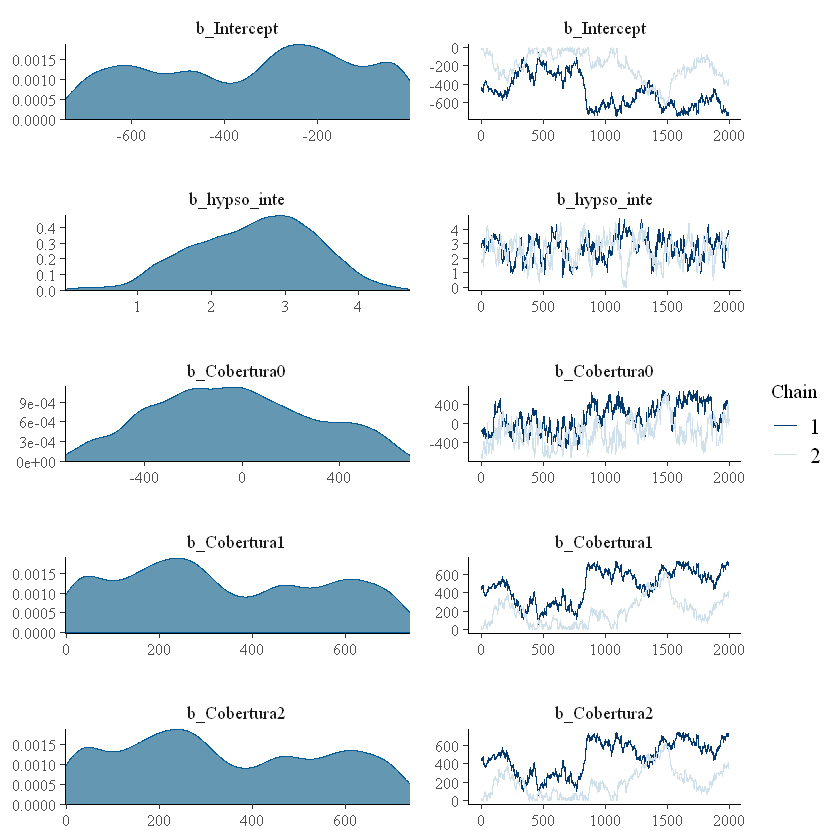

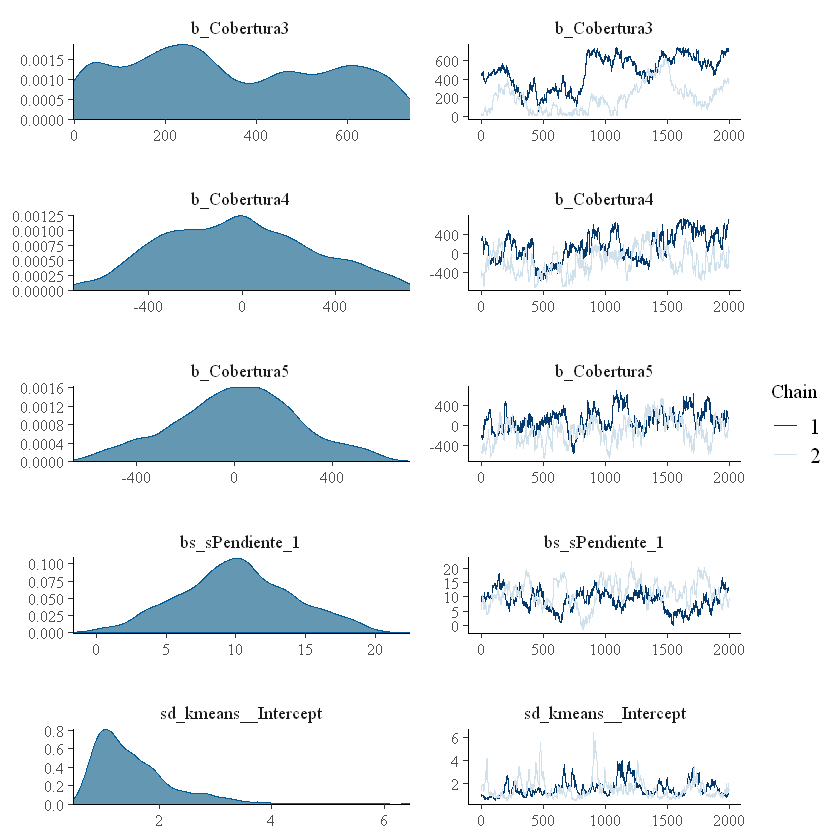

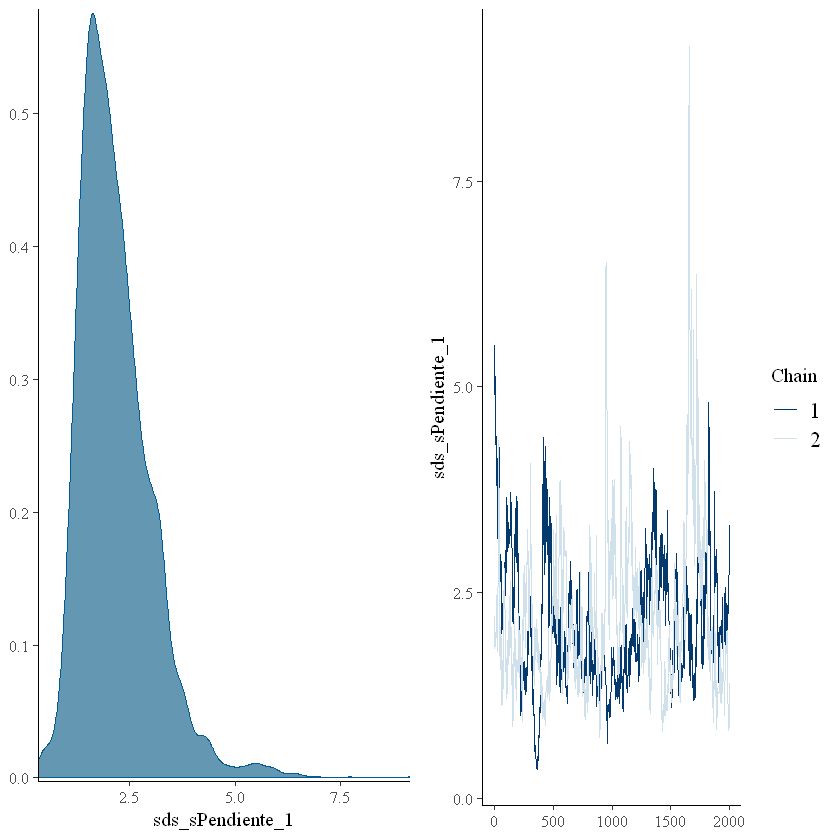

In [212]:
plot(bhglm)